In [2]:
import sys
print(sys.executable)

c:\Users\bhara\OneDrive\Desktop\neural_stock\.venv\Scripts\python.exe


In [3]:
import joblib
print(joblib.__version__)

1.5.3


In [4]:
# Import Required Libraries and Set Random Seed
import warnings
warnings.filterwarnings("ignore")

import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
df = pd.read_csv("../data/ecommerce_inventory_demand.csv")

df.head()

,date,product_id,product_category,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,day_of_week,month,supplier_lead_days
0,2022-06-27,P006,Electronics,NaN,10225.02,203,79,0,0.0,0,6,13
1,2023-06-14,P028,Apparel,NaN,1137.33,108,51,0,0.0,2,6,8
2,2022-06-20,P005,Electronics,NaN,8245.58,274,72,0,0.0,0,6,9
3,2022-03-06,P039,Home,NaN,2657.76,179,43,0,0.0,6,3,12
4,2022-05-01,P015,Electronics,NaN,12117.51,205,52,0,0.0,6,5,8


In [6]:
# Check Dataset Shape

df.shape

(6223, 12)

In [7]:
# Check Column Names

df.columns

Index(['date', 'product_id', 'product_category', 'units_sold', 'unit_price',
       'stock_on_hand', 'reorder_point', 'is_promotion', 'discount_pct',
       'day_of_week', 'month', 'supplier_lead_days'],
      dtype='str')

In [8]:
# Check Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6223 entries, 0 to 6222
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                6223 non-null   str    
 1   product_id          6223 non-null   str    
 2   product_category    6223 non-null   str    
 3   units_sold          5974 non-null   float64
 4   unit_price          6223 non-null   float64
 5   stock_on_hand       6223 non-null   int64  
 6   reorder_point       6223 non-null   int64  
 7   is_promotion        6223 non-null   int64  
 8   discount_pct        6223 non-null   float64
 9   day_of_week         6223 non-null   int64  
 10  month               6223 non-null   int64  
 11  supplier_lead_days  6223 non-null   int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 719.9 KB


In [9]:
# Statistical Summary

df.describe()

,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,day_of_week,month,supplier_lead_days
count,5974.000000,6223.000000,6223.000000,6223.000000,6223.000000,6223.000000,6223.000000,6223.000000,6223.000000
mean,28.372782,9153.228877,122.621887,49.014945,0.056886,1.953736,3.018801,6.470673,8.268038
std,14.032411,16741.874355,72.709263,17.514845,0.231643,8.645728,2.001880,3.464853,3.744854
min,5.000000,705.520000,-365.000000,20.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,19.000000,2011.130000,72.000000,36.000000,0.000000,0.000000,1.000000,3.000000,5.000000
50%,25.000000,4863.620000,111.000000,51.000000,0.000000,0.000000,3.000000,6.000000,8.000000
75%,34.000000,13299.370000,165.000000,60.000000,0.000000,0.000000,5.000000,9.000000,12.000000
max,158.000000,246143.800000,387.000000,79.000000,1.000000,60.000000,6.000000,12.000000,14.000000


In [10]:
# Check Missing Values

df.isnull().sum()

date                    0
product_id              0
product_category        0
units_sold            249
unit_price              0
stock_on_hand           0
reorder_point           0
is_promotion            0
discount_pct            0
day_of_week             0
month                   0
supplier_lead_days      0
dtype: int64

In [11]:
# Convert Date Column to Datetime

df["date"] = pd.to_datetime(df["date"])

In [12]:
# Sort Dataset by Date

df = df.sort_values("date")

In [13]:
# Forward Fill Missing Values

df = df.ffill()

In [14]:
# Convert Units Sold to Integer

df["units_sold"] = df["units_sold"].astype(int)

In [15]:
# Verify Missing Values After Filling

df.isnull().sum()

date                  0
product_id            0
product_category      0
units_sold            0
unit_price            0
stock_on_hand         0
reorder_point         0
is_promotion          0
discount_pct          0
day_of_week           0
month                 0
supplier_lead_days    0
dtype: int64

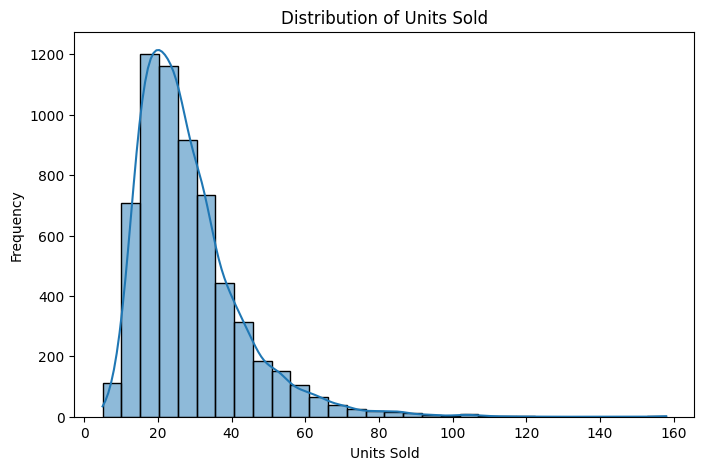

In [16]:
# Plot Histogram for Units Sold

plt.figure(figsize=(8, 5))
sns.histplot(df["units_sold"], bins=30, kde=True)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

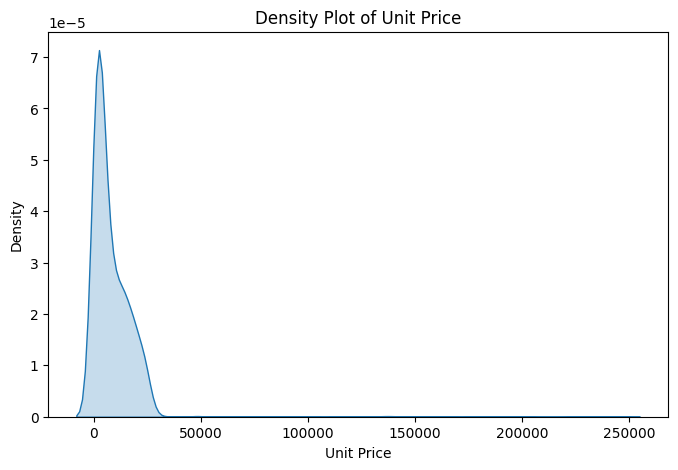

In [17]:
# Density Plot for Unit Price

plt.figure(figsize=(8, 5))
sns.kdeplot(df["unit_price"], fill=True)
plt.title("Density Plot of Unit Price")
plt.xlabel("Unit Price")
plt.show()

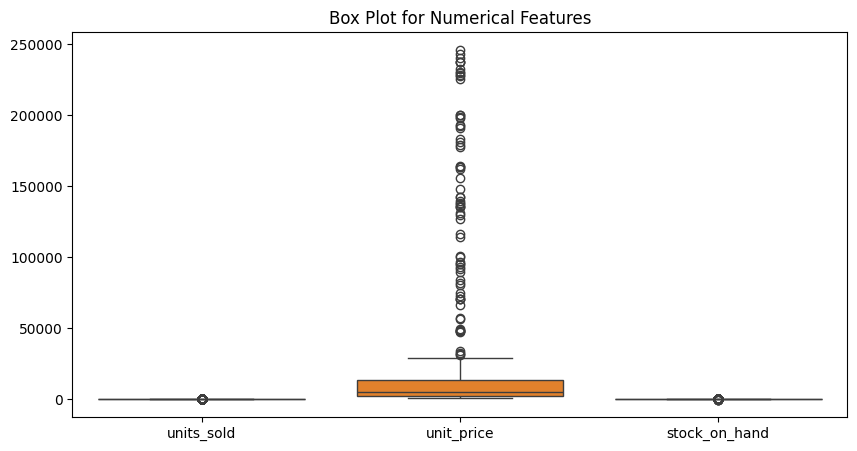

In [18]:
# Box Plot for Numerical Columns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["units_sold", "unit_price", "stock_on_hand"]])
plt.title("Box Plot for Numerical Features")
plt.show()

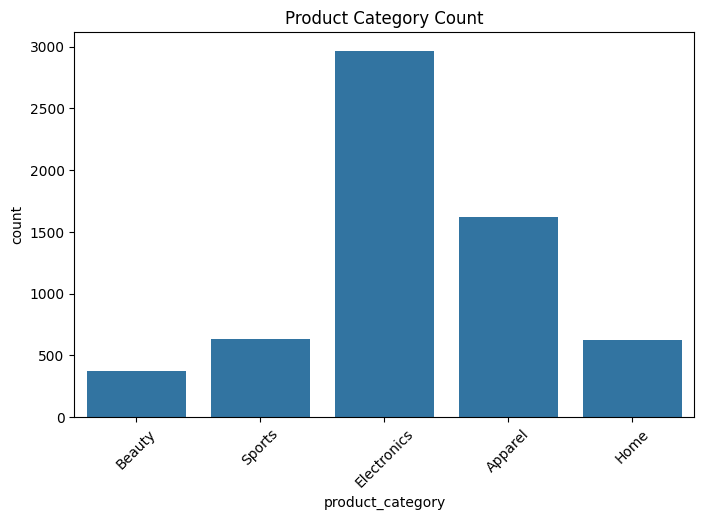

In [19]:
# Bar Plot for Product Category

plt.figure(figsize=(8, 5))
sns.countplot(x="product_category", data=df)
plt.title("Product Category Count")
plt.xticks(rotation=45)
plt.show()

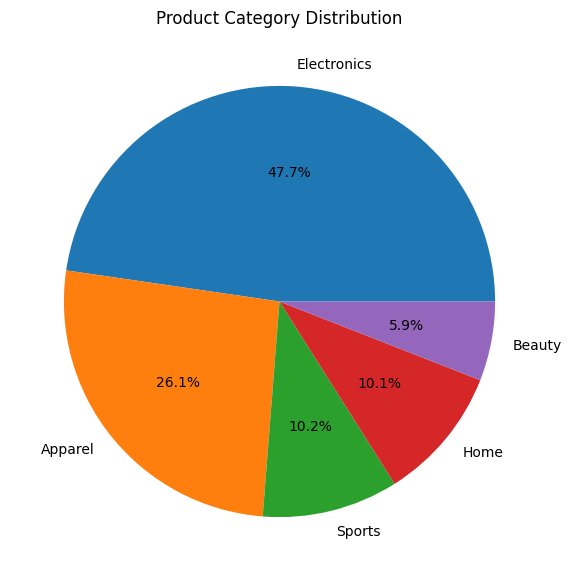

In [20]:
# Pie Chart for Product Category Distribution

category_counts = df["product_category"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%")
plt.title("Product Category Distribution")
plt.show()

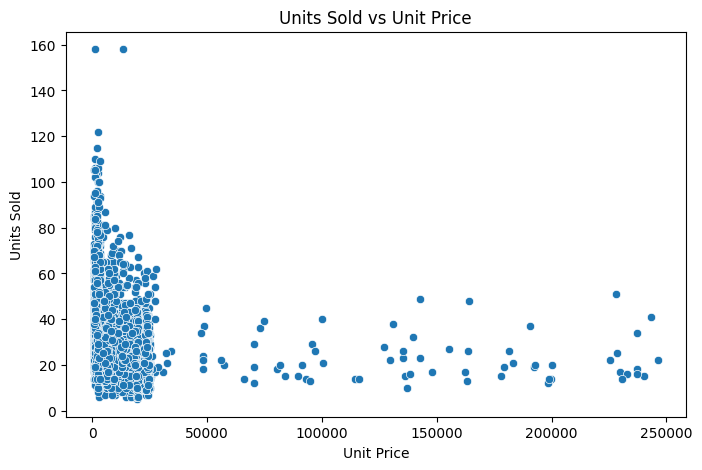

In [21]:
# Scatter Plot for Units Sold vs Unit Price

plt.figure(figsize=(8, 5))
sns.scatterplot(x="unit_price", y="units_sold", data=df)
plt.title("Units Sold vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.show()

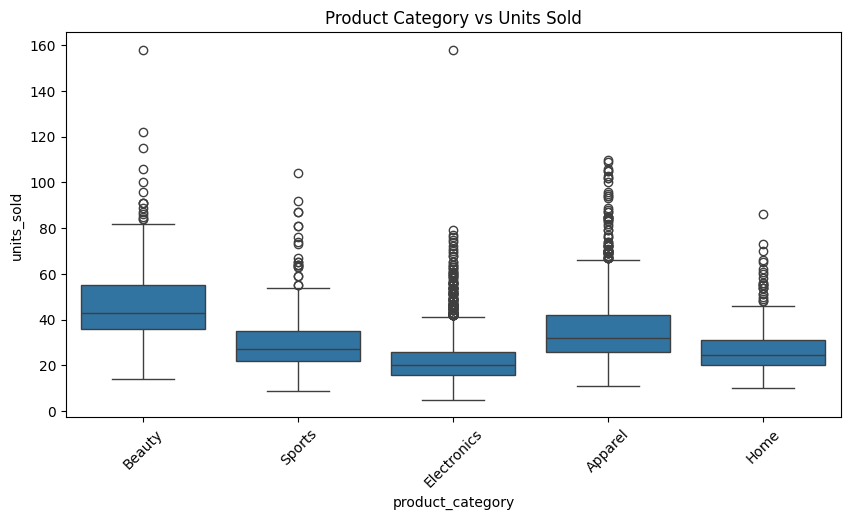

In [22]:
# Box Plot for Product Category vs Units Sold

plt.figure(figsize=(10, 5))
sns.boxplot(x="product_category", y="units_sold", data=df)
plt.title("Product Category vs Units Sold")
plt.xticks(rotation=45)
plt.show()

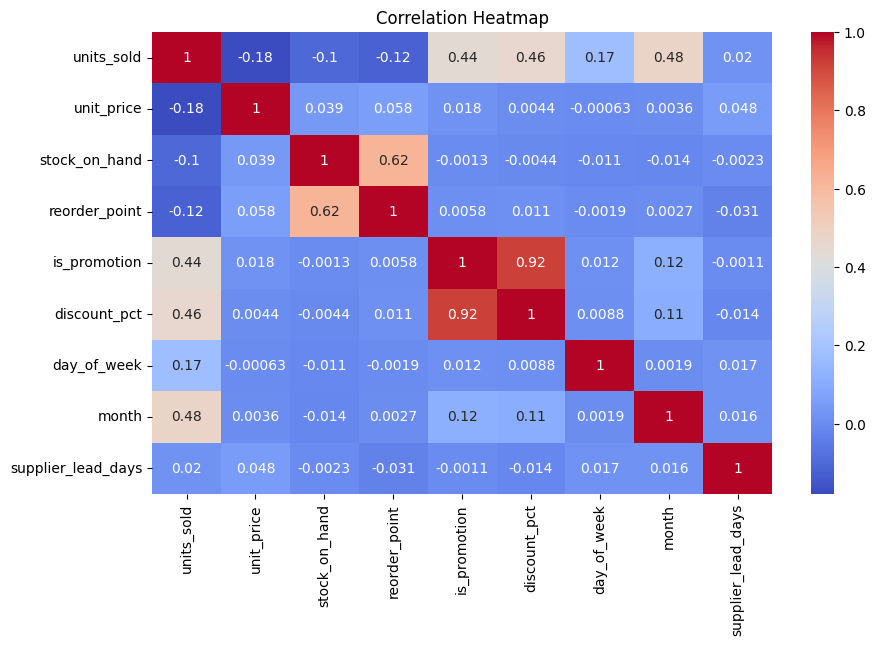

In [23]:
# Heatmap for Correlation Analysis

plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

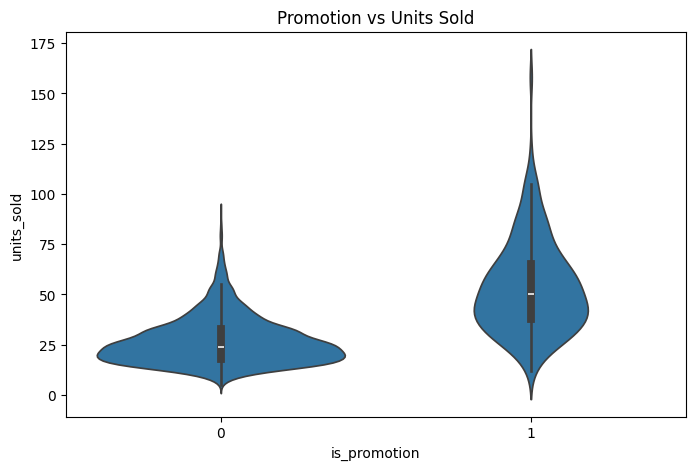

In [24]:
# Violin Plot for Promotion vs Units Sold

plt.figure(figsize=(8, 5))
sns.violinplot(x="is_promotion", y="units_sold", data=df)
plt.title("Promotion vs Units Sold")
plt.show()

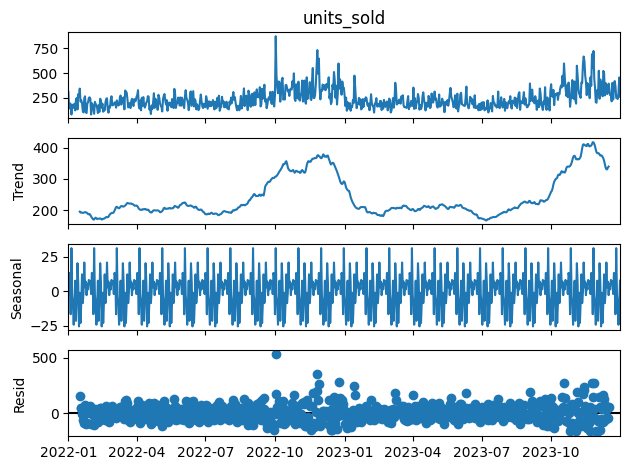

In [25]:
# Seasonal Decomposition for Units Sold

daily_sales = df.groupby("date")["units_sold"].sum()

decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=30
)

decomposition.plot()
plt.show()

<Figure size 1000x500 with 0 Axes>

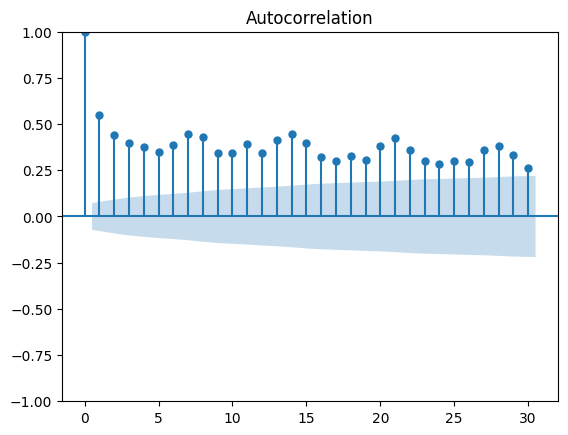

In [26]:
# Auto Correlation Function Plot

plt.figure(figsize=(10, 5))

plot_acf(daily_sales, lags=30)

plt.show()

<Figure size 1000x500 with 0 Axes>

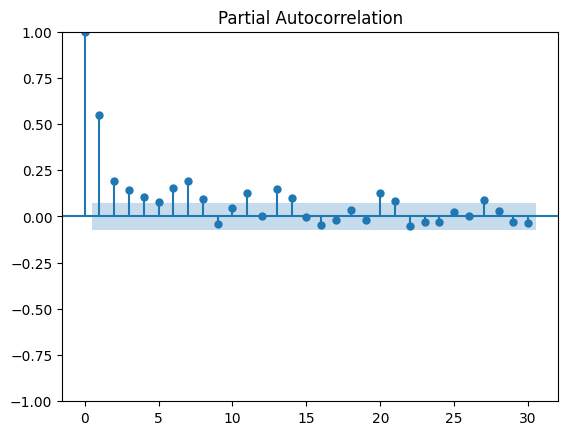

In [27]:
# Partial Auto Correlation Function Plot

plt.figure(figsize=(10, 5))

plot_pacf(daily_sales, lags=30)

plt.show()

In [28]:
# Detect Outliers Using IQR Method for Unit Price

Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["unit_price"] < lower_bound) |
    (df["unit_price"] > upper_bound)
]

print(outliers.shape)

(71, 12)


In [29]:
# Correct Unit Price Outliers

median_price = df["unit_price"].median()

df.loc[
    (df["unit_price"] < lower_bound) |
    (df["unit_price"] > upper_bound),
    "unit_price"
] = median_price

In [30]:
# Create Lag Features

df["lag_7"] = df["units_sold"].shift(7)
df["lag_14"] = df["units_sold"].shift(14)

In [31]:
# Create Rolling Mean Features

df["rolling_mean_7"] = df["units_sold"].rolling(window=7).mean()
df["rolling_mean_30"] = df["units_sold"].rolling(window=30).mean()

In [32]:
# Create Rolling Standard Deviation Features

df["rolling_std_7"] = df["units_sold"].rolling(window=7).std()
df["rolling_std_30"] = df["units_sold"].rolling(window=30).std()

In [33]:
# Create Date Based Features

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

In [34]:
# Create Weekend Feature

df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

In [35]:
# Drop Null Values Generated by Lag Features

df = df.dropna()

In [36]:
# One Hot Encoding for Categorical Columns

df = pd.get_dummies(
    df,
    columns=["product_category", "day_of_week"],
    drop_first=True
)

In [37]:
# Check Dataset After Feature Engineering

df.head()

,date,product_id,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,month,supplier_lead_days,...,product_category_Beauty,product_category_Electronics,product_category_Home,product_category_Sports,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
1066,2022-01-04,P008,27,1984.38,86,20,0,0.0,1,10,...,True,False,False,False,True,False,False,False,False,False
1357,2022-01-04,P006,18,10331.62,87,79,0,0.0,1,13,...,False,True,False,False,True,False,False,False,False,False
4237,2022-01-04,P045,15,16276.81,33,21,0,0.0,1,13,...,False,True,False,False,True,False,False,False,False,False
368,2022-01-04,P042,17,1192.93,32,31,0,0.0,1,8,...,False,False,False,False,True,False,False,False,False,False
734,2022-01-04,P015,15,12489.18,140,52,0,0.0,1,8,...,False,True,False,False,True,False,False,False,False,False


In [38]:
# Define Features and Target

X = df.drop(
    columns=[
        "units_sold",
        "date",
        "product_id"
    ]
)

y = df["units_sold"]

In [39]:
# Train Test Split Without Shuffling

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [40]:
# Apply MinMax Scaling

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
# Save Scaler

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [42]:
# Check Training and Testing Shapes

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4955, 26)
(1239, 26)


In [43]:
# Create Sliding Window Sequences

def create_sequences(features, target, sequence_length):
    
    X_seq = []
    y_seq = []

    for i in range(len(features) - sequence_length):
        
        X_seq.append(features[i:i + sequence_length])
        y_seq.append(target.iloc[i + sequence_length])

    return np.array(X_seq), np.array(y_seq)

In [44]:
# Define Sequence Length

sequence_length = 14

In [45]:
# Generate Training Sequences

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    sequence_length
)

In [46]:
# Generate Testing Sequences

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    sequence_length
)

In [47]:
# Convert Data to PyTorch Tensors

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

In [48]:
# Create DataLoader

train_dataset = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = torch.utils.data.TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [49]:
# Define LSTM Model

class LSTMModel(nn.Module):

    def __init__(self, input_size):

        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        output, _ = self.lstm(x)

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [50]:
# Initialize LSTM Model

input_size = X_train_seq.shape[2]

lstm_model = LSTMModel(input_size)

In [51]:
# Define MLP Baseline Model

class MLPModel(nn.Module):

    def __init__(self, input_size):

        super(MLPModel, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.model(x)

In [52]:
# Initialize MLP Model

mlp_input_size = sequence_length * X_train_seq.shape[2]

mlp_model = MLPModel(mlp_input_size)

In [53]:
# Define Loss Function and Optimizer

criterion = nn.MSELoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

In [54]:
# Train LSTM Model

lstm_losses = []

epochs = 20

for epoch in range(epochs):

    lstm_model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        lstm_optimizer.zero_grad()

        outputs = lstm_model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        lstm_optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    lstm_losses.append(average_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {average_loss:.4f}")

Epoch 1/20, Loss: 505.8813
Epoch 2/20, Loss: 257.1679
Epoch 3/20, Loss: 184.9081
Epoch 4/20, Loss: 165.9098
Epoch 5/20, Loss: 162.0980
Epoch 6/20, Loss: 161.6352
Epoch 7/20, Loss: 161.7181
Epoch 8/20, Loss: 161.8426
Epoch 9/20, Loss: 161.9459
Epoch 10/20, Loss: 162.0287
Epoch 11/20, Loss: 162.0961
Epoch 12/20, Loss: 162.1518
Epoch 13/20, Loss: 162.1981
Epoch 14/20, Loss: 162.2369
Epoch 15/20, Loss: 162.2695
Epoch 16/20, Loss: 162.2970
Epoch 17/20, Loss: 162.3201
Epoch 18/20, Loss: 162.3397
Epoch 19/20, Loss: 162.3562
Epoch 20/20, Loss: 162.3702


In [55]:
# Train MLP Model

mlp_losses = []

for epoch in range(epochs):

    mlp_model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        mlp_optimizer.zero_grad()

        outputs = mlp_model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        mlp_optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    mlp_losses.append(average_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {average_loss:.4f}")

Epoch 1/20, Loss: 180.0959
Epoch 2/20, Loss: 104.1363
Epoch 3/20, Loss: 101.8492
Epoch 4/20, Loss: 100.5089
Epoch 5/20, Loss: 99.5447
Epoch 6/20, Loss: 98.8093
Epoch 7/20, Loss: 98.1845
Epoch 8/20, Loss: 97.6316
Epoch 9/20, Loss: 97.1197
Epoch 10/20, Loss: 96.6187
Epoch 11/20, Loss: 96.0960
Epoch 12/20, Loss: 95.5487
Epoch 13/20, Loss: 94.9969
Epoch 14/20, Loss: 94.4188
Epoch 15/20, Loss: 93.8132
Epoch 16/20, Loss: 93.2142
Epoch 17/20, Loss: 92.5660
Epoch 18/20, Loss: 91.9768
Epoch 19/20, Loss: 91.3401
Epoch 20/20, Loss: 90.7849


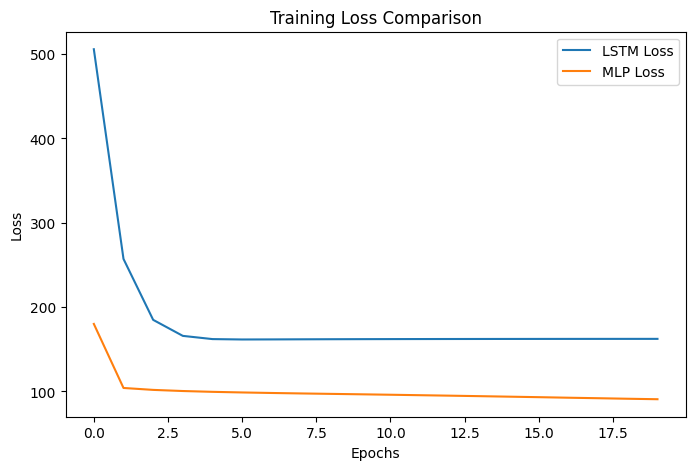

In [56]:
# Plot Training Loss

plt.figure(figsize=(8, 5))

plt.plot(lstm_losses, label="LSTM Loss")
plt.plot(mlp_losses, label="MLP Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()

plt.show()

In [57]:
# Evaluate LSTM Model

lstm_model.eval()

with torch.no_grad():

    lstm_predictions = lstm_model(X_test_tensor).squeeze().numpy()

In [58]:
# Evaluate MLP Model

mlp_model.eval()

with torch.no_grad():

    mlp_predictions = mlp_model(X_test_tensor).squeeze().numpy()

In [59]:
# Calculate Evaluation Metrics Function

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2

In [60]:
# Evaluate LSTM Predictions

lstm_mae, lstm_rmse, lstm_mape, lstm_r2 = evaluate_model(
    y_test_seq,
    lstm_predictions
)

print("LSTM Model Performance")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)
print("R2 Score:", lstm_r2)

LSTM Model Performance
MAE: 13.527029991149902
RMSE: 19.27413022544119
MAPE: 33.46151601480551
R2 Score: -0.3528822660446167


In [61]:
# Evaluate MLP Predictions

mlp_mae, mlp_rmse, mlp_mape, mlp_r2 = evaluate_model(
    y_test_seq,
    mlp_predictions
)

print("MLP Model Performance")
print("MAE:", mlp_mae)
print("RMSE:", mlp_rmse)
print("MAPE:", mlp_mape)
print("R2 Score:", mlp_r2)

MLP Model Performance
MAE: 13.81049919128418
RMSE: 18.91892976149318
MAPE: 32.796558223522005
R2 Score: -0.30347752571105957


In [62]:
# Feature Importance Analysis

feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": np.abs(X_train).mean()
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                         Feature   Importance
unit_price            unit_price  7688.621181
stock_on_hand      stock_on_hand   125.441171
reorder_point      reorder_point    48.947124
rolling_mean_30  rolling_mean_30    26.362503
rolling_mean_7    rolling_mean_7    26.362260
lag_7                      lag_7    26.359637
lag_14                    lag_14    26.356004
day                          day    15.686983
rolling_std_30    rolling_std_30     9.402525
rolling_std_7      rolling_std_7     8.596819


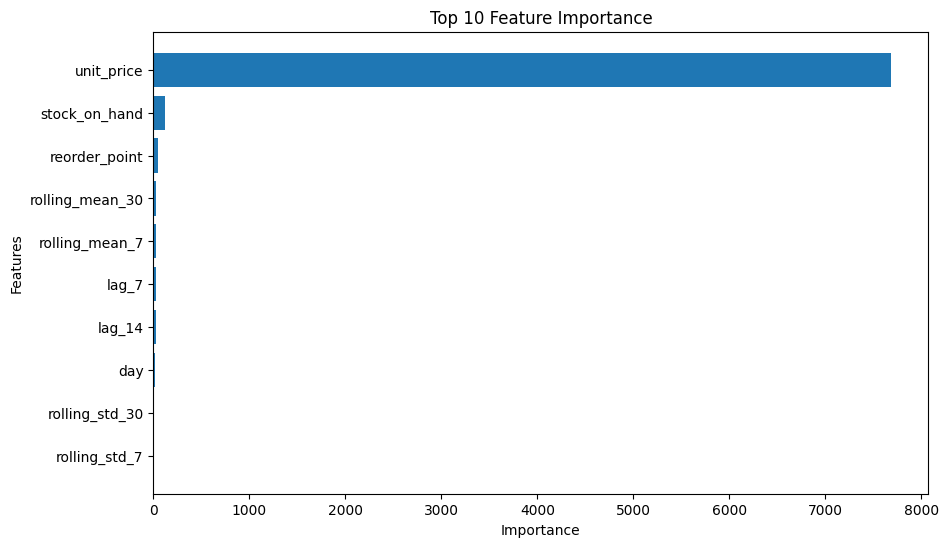

In [63]:
# Plot Feature Importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [74]:
# Confidence Intervals

prediction_std = np.std(lstm_predictions)

lower_bound = np.mean(lstm_predictions) - 1.96 * prediction_std
upper_bound = np.mean(lstm_predictions) + 1.96 * prediction_std

print("95% Confidence Interval")
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

95% Confidence Interval
Lower Bound: 26.58
Upper Bound: 26.58


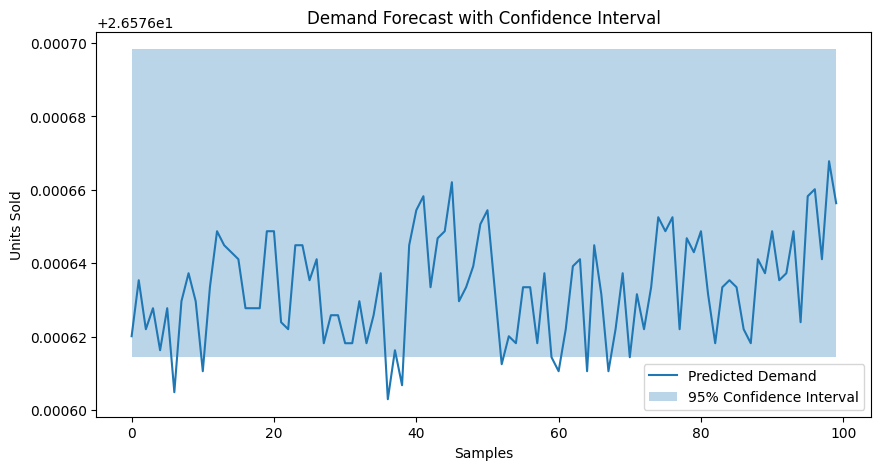

In [75]:
# Confidence Interval Visualization

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_predictions[:100],
    label="Predicted Demand"
)

plt.fill_between(
    range(len(lstm_predictions[:100])),
    lower_bound,
    upper_bound,
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Demand Forecast with Confidence Interval")
plt.xlabel("Samples")
plt.ylabel("Units Sold")

plt.legend()

plt.show()

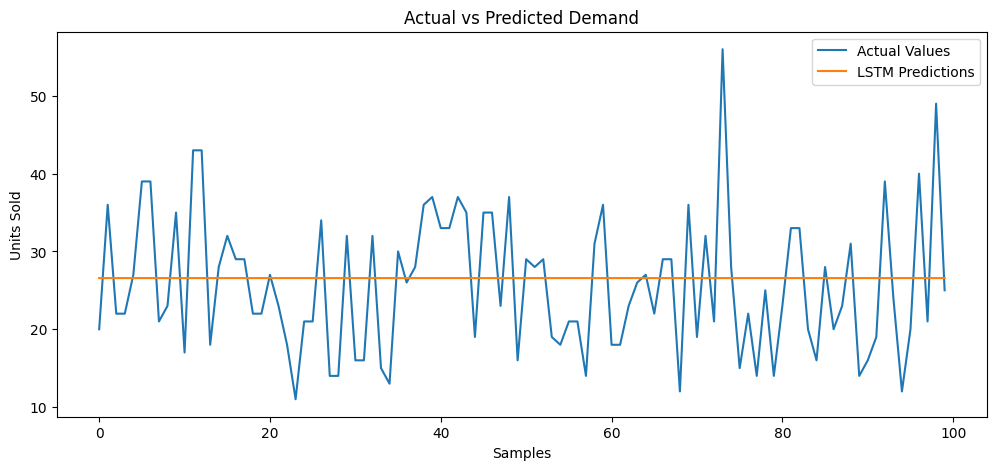

In [64]:
# Plot Actual vs Predicted Values for LSTM

plt.figure(figsize=(12, 5))

plt.plot(y_test_seq[:100], label="Actual Values")
plt.plot(lstm_predictions[:100], label="LSTM Predictions")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Samples")
plt.ylabel("Units Sold")

plt.legend()

plt.show()

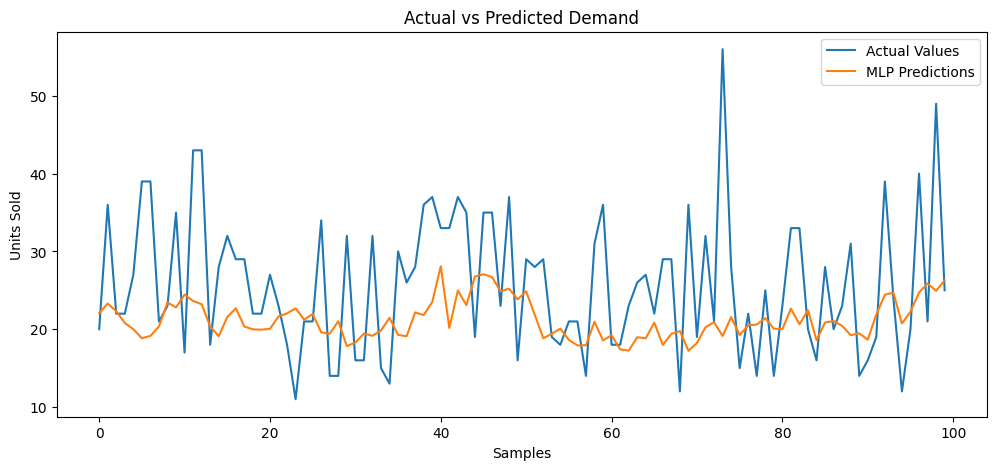

In [65]:
# Plot Actual vs Predicted Values for MLP

plt.figure(figsize=(12, 5))

plt.plot(y_test_seq[:100], label="Actual Values")
plt.plot(mlp_predictions[:100], label="MLP Predictions")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Samples")
plt.ylabel("Units Sold")

plt.legend()

plt.show()

In [66]:
# Save LSTM Model

torch.save(
    lstm_model.state_dict(),
    "../models/lstm_model.pt"
)

In [67]:
# Save MLP Model

torch.save(
    mlp_model.state_dict(),
    "../models/mlp_model.pt"
)

In [68]:
# Display Final Insights

print("Project Completed Successfully")

print("\nLSTM Model Metrics")
print(f"MAE  : {lstm_mae:.2f}")
print(f"RMSE : {lstm_rmse:.2f}")
print(f"MAPE : {lstm_mape:.2f}%")
print(f"R2   : {lstm_r2:.2f}")

print("\nMLP Model Metrics")
print(f"MAE  : {mlp_mae:.2f}")
print(f"RMSE : {mlp_rmse:.2f}")
print(f"MAPE : {mlp_mape:.2f}%")
print(f"R2   : {mlp_r2:.2f}")

Project Completed Successfully

LSTM Model Metrics
MAE  : 13.53
RMSE : 19.27
MAPE : 33.46%
R2   : -0.35

MLP Model Metrics
MAE  : 13.81
RMSE : 18.92
MAPE : 32.80%
R2   : -0.30


In [69]:
# Check Best Performing Model

if lstm_rmse < mlp_rmse:
    print("\nLSTM Model Performs Better")
else:
    print("\nMLP Model Performs Better")


MLP Model Performs Better


In [70]:
# Display Dataset Shape After Processing

print("Final Dataset Shape :", df.shape)

Final Dataset Shape : (6194, 29)


In [71]:
# Display Sample Data

df.head()

,date,product_id,units_sold,unit_price,stock_on_hand,reorder_point,is_promotion,discount_pct,month,supplier_lead_days,...,product_category_Beauty,product_category_Electronics,product_category_Home,product_category_Sports,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
1066,2022-01-04,P008,27,1984.38,86,20,0,0.0,1,10,...,True,False,False,False,True,False,False,False,False,False
1357,2022-01-04,P006,18,10331.62,87,79,0,0.0,1,13,...,False,True,False,False,True,False,False,False,False,False
4237,2022-01-04,P045,15,16276.81,33,21,0,0.0,1,13,...,False,True,False,False,True,False,False,False,False,False
368,2022-01-04,P042,17,1192.93,32,31,0,0.0,1,8,...,False,False,False,False,True,False,False,False,False,False
734,2022-01-04,P015,15,12489.18,140,52,0,0.0,1,8,...,False,True,False,False,True,False,False,False,False,False


In [72]:
# Save Cleaned Dataset

df.to_csv(
    "../data/cleaned_ecommerce_inventory_demand.csv",
    index=False
)

In [73]:
# Check Saved Files

import os

print(os.listdir("../models"))

['lstm_model.pt', 'mlp_model.pt', 'scaler.pkl']


## TensorBoard Visualization

TensorBoard was used to monitor the training process of the LSTM model.

Observations:

- Training loss decreased significantly during initial epochs.
- The model gradually converged after multiple iterations.
- TensorBoard provided real-time visualization of model performance.

Tool Used:
- PyTorch SummaryWriter
- TensorBoard

Logged Metric:
- Training Loss

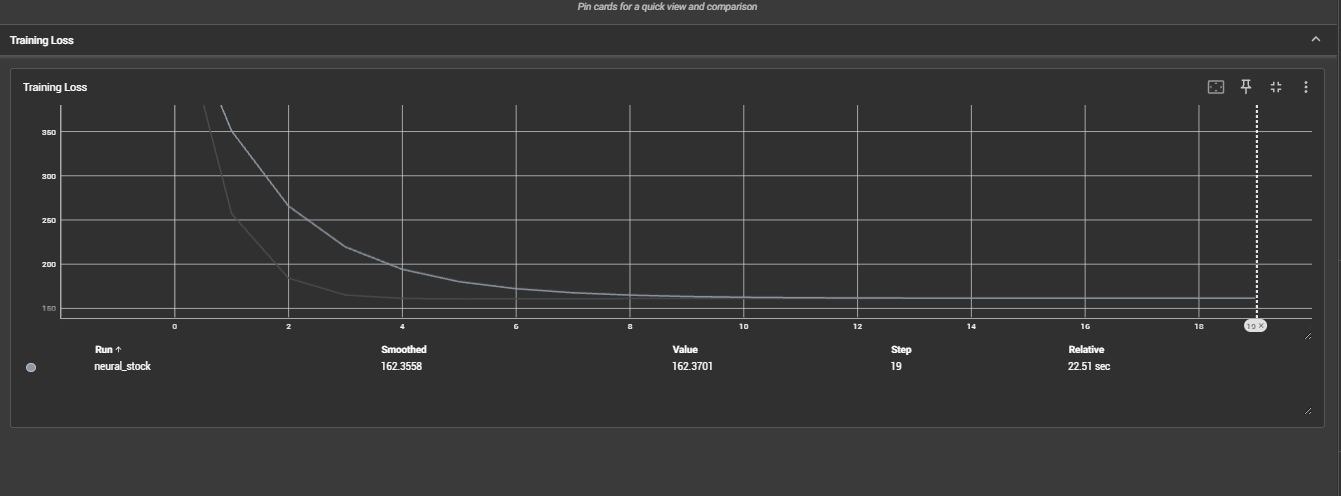